#  Problem 3

### Problem
$$
\begin{align*}
u(x,y) &= \frac{e^x+e^y}{1+xy}
\end{align*}
$$

From the Paper:

Relative errors for the Dirichlet and Neumann problems can be found in Table IV. The
number of Fourier coefficients was kept constant N = 64. Again, the ratio between two
consecutive errors in norm k·k2 is constant and equals either 4 or 8. The same problem
was also solved for the disk B(0; 0.5), and the relative errors for N = 64 are presented in Table V. As it was expected, the accuracy is higher for R = 0.5 because of larger density
of points in the domain discretization.

# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_2,
    display_table_varying_M
)




# Problem Setup

In [2]:
# Problem Setup — Problem 3 (Borges–Daripa JCP)

# Radii for Tables 4 and 5
R1 = 1.0    # unit disk B(0,1)
R2 = 0.5    # disk B(0,0.5)

# Radial mesh type: keep radial grid uniform here
rad_unif = 1

x, y = sp.symbols('x y')
u_sym = (sp.exp(x) + sp.exp(y)) / (1.0 + x * y)
u, f, g_dirichlet, g_neumann = get_problem_functions(u_sym, x, y)

# N and M values (Problem 3: Tables 4 and 5 use fixed N = 64, varying M)
M_values = [64, 128, 256, 512, 1024, 2048]
N_fixed  = 64

# ----------------------------------------------------------
# Methods to test
# ----------------------------------------------------------
methods = [
    dict(
        name="uniform_fft",
        label="Uniform Mesh",
        azu_unif=2,
        mesh_kind=None,
        use_nudft=None,
    ),
]

BC_MAP = {
    "dirichlet": 1,
    "neumann": 2,
}

QUAD_MAP = {
    "trapezoidal": 1,
    "simpson": 2,
}

# Run Code, table 4 and 5

In [3]:
# Table 4: R = R1 (unit disk)
df_table4 = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R1)

# Table 5: R = R2 (B(0,0.5))
df_table5 = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R2)


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


# View Results

In [4]:
display_table_varying_M(df_table4, methods, M_values, f"TABLE 4 (Problem 3, R = {R1})")
display_table_varying_M(df_table5, methods, M_values, f"TABLE 5 (Problem 3, R = {R2})")



Uniform Mesh : TABLE 4 (Problem 3, R = 1.0)


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            1.1e-04  1.0e-04   6.3e-04  3.4e-04      2.3e-05  1.8e-05   
128           2.9e-05  2.5e-05   1.5e-04  8.4e-05      3.2e-06  2.3e-06   
256           7.5e-06  6.2e-06   3.8e-05  2.1e-05      6.2e-07  2.9e-07   
512           2.0e-06  1.5e-06   9.5e-06  5.2e-06      1.3e-07  3.7e-08   
1024          5.1e-07  3.9e-07   2.4e-06  1.3e-06      3.0e-08  4.6e-09   
2048          1.3e-07  9.6e-08   5.9e-07  3.2e-07      7.2e-09  5.9e-10   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     2.0e-05  9.5e-06  
128    2.6e-06  1.2e-06  
256    3.2e-07  1.5e-07  
512    4.0e-08  1.8e-08  
1024   5.2e-09  2.3e-09  
2048   8.7e-10  3.0e-10


Uniform Mesh : TABLE 5 (Problem 3, R = 0.5)


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            3.1e-05  5.4e-06   7.8e-06  3.6e-06      3.7e-06  4.0e-08   
128           8.2e-06  1.3e-06   1.9e-06  8.7e-07      9.0e-07  4.8e-09   
256           2.2e-06  3.3e-07   4.7e-07  2.2e-07      2.2e-07  5.9e-10   
512           5.9e-07  8.2e-08   1.2e-07  5.4e-08      5.5e-08  7.3e-11   
1024          1.6e-07  2.1e-08   2.9e-08  1.3e-08      1.4e-08  9.0e-12   
2048          4.2e-08  5.1e-09   7.3e-09  3.4e-09      3.4e-09  1.1e-12   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     5.8e-08  1.9e-08  
128    7.1e-09  2.2e-09  
256    8.8e-10  2.7e-10  
512    1.1e-10  3.4e-11  
1024   1.4e-11  4.2e-12  
2048   1.7e-12  5.2e-13

## Figures from Original Paper

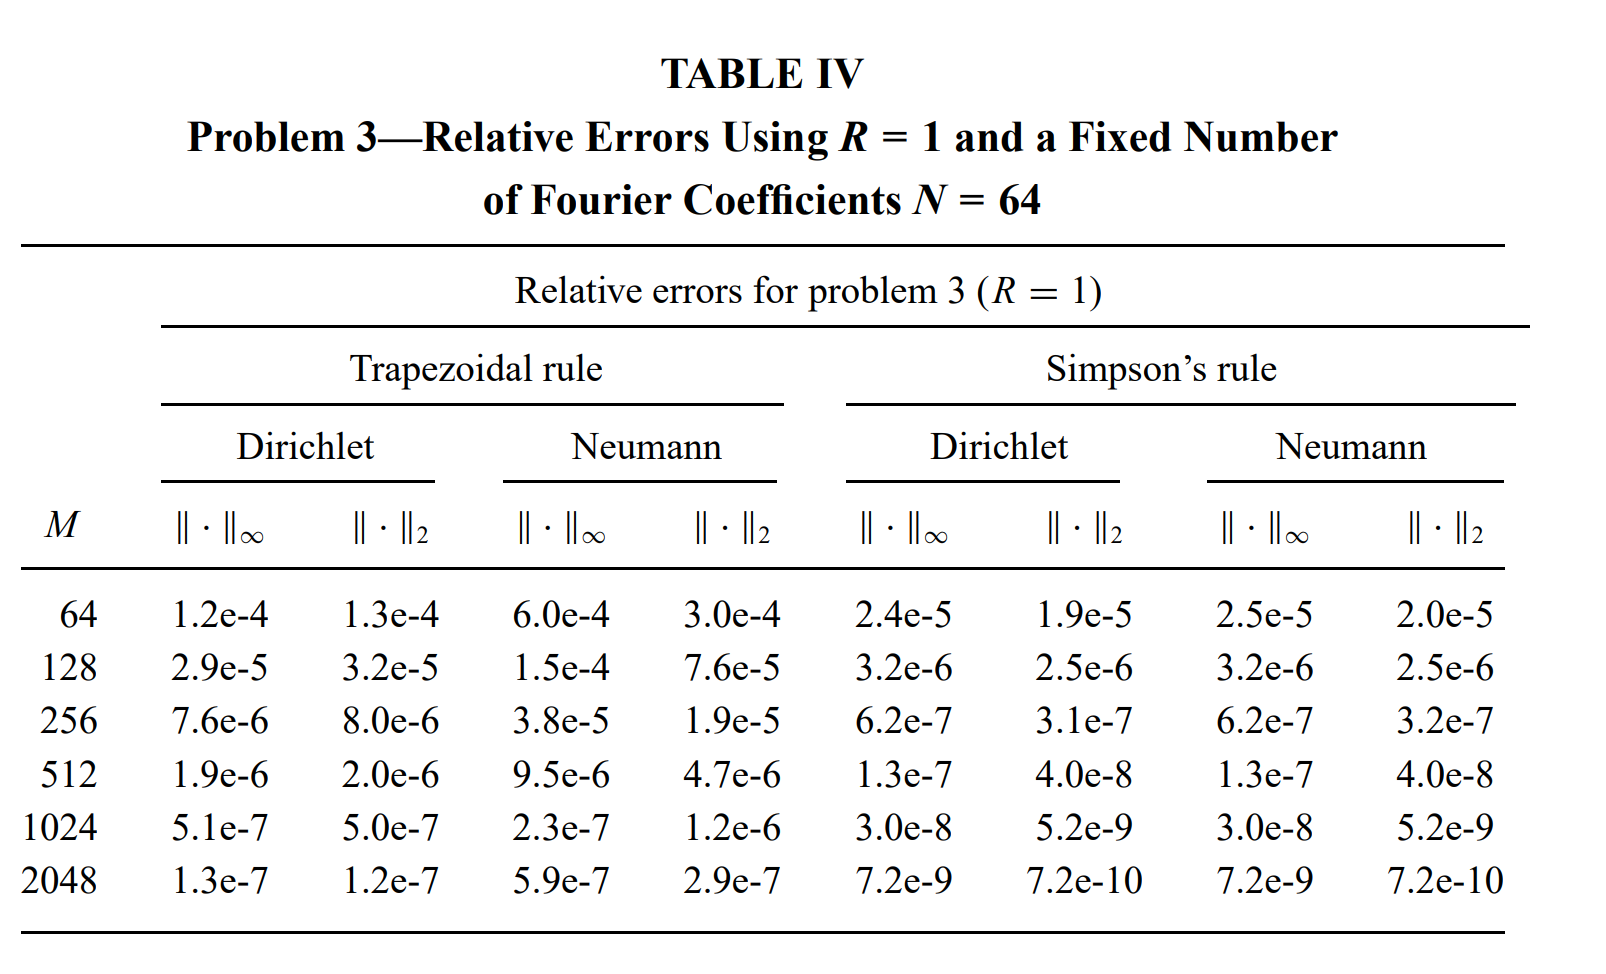

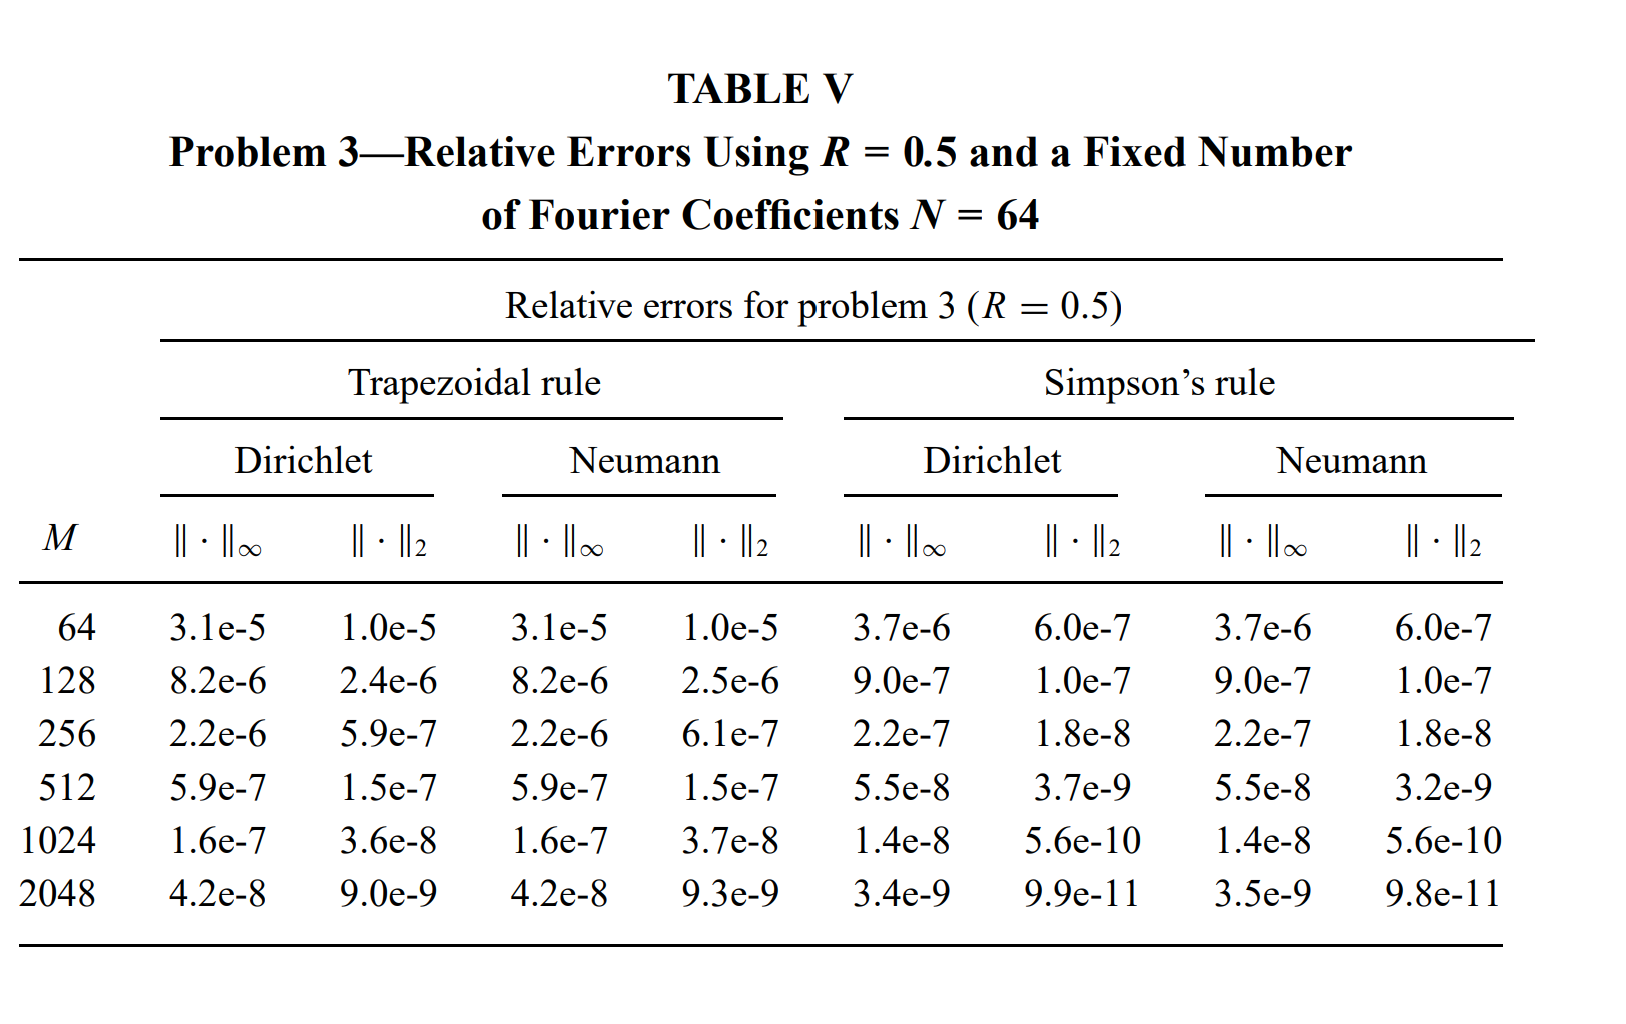